# 05 — MPE Microtonal Tokenizer (53-TET)

## Dual-Channel Tokenization for GPT-2 Training

This notebook is the **canonical reference** for the tokenization pipeline.
It uses the production tokenizer from `tokenizer.py` and the
4D EigenSpace embedding from `eigenspace.py`.

### Dual-Channel Architecture

| Channel | Data | Shape | Purpose |
|---------|------|-------|---------|
| **Ch 1 — Tokens** | `token_ids` (uint16) | `(N,)` | Token embedding → self-attention |
| **Ch 2 — EigenSpace** | `(α, β, γ, δ)` (float32) | `(N, 4)` | Harmonic positional encoding |

### Token Format (per chord)

```
CHORD_START  DUR_<beats>  ROOT_<0-52>  PV_<step>_<vel> ... PV_<step>_<vel>  CHORD_END
```

### EigenSpace 4D — Harmonic DNA

| Axis | Symbol | Meaning | Range |
|------|--------|---------|-------|
| α | 3rd ratio | Major/minor quality | 1.0 – 1.26 |
| β | 5th ratio | Perfect/aug/dim | 1.0 – 1.5 |
| γ | 7th ratio | Dominant/major/minor 7th | 1.0 – 2.0 |
| δ | Root ratio | Root pitch class = 2^(root_pc/53) | 1.0 – 2.0 |

> **Key insight**: Dissonance is root-dependent — the same interval pattern
> on different root pitch classes produces different harmonic series interactions.
> The δ axis captures this, making `(α, β, γ, δ)` a complete harmonic fingerprint.
> Two chords share the same dissonance only if ALL four coordinates match.

In [ ]:
import sys, os, json, importlib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

# ── Path setup ────────────────────────────────────────────────────────────
SRC_DIR  = Path('.').resolve()
ROOT_DIR = SRC_DIR.parent
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# ── Import production modules ────────────────────────────────────────────
from tokenizer import MPETokenizer, parse_mpe_midi

from eigenspace import (
    EigenSpaceComputer, classify_intervals, get_53tet_ratio,
    DEFAULT_ALPHA, DEFAULT_BETA, DEFAULT_GAMMA, DEFAULT_DELTA, N_EIGEN, TET_53,
)

# ── Directories ──────────────────────────────────────────────────────────
MIDI_DIR   = ROOT_DIR / 'dataset' / 'midi_files' / '53_tet_mpe'
OUTPUT_DIR = ROOT_DIR / 'dataset' / 'preprocessed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Source:     {SRC_DIR}")
print(f"MIDI dir:   {MIDI_DIR}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"EigenSpace: {N_EIGEN}D (α, β, γ, δ)")

Source:     /home/david/Projects/ANIMA_Data_Formation/src
MIDI dir:   /home/david/Projects/ANIMA_Data_Formation/dataset/midi_files/53_tet_mpe
Output dir: /home/david/Projects/ANIMA_Data_Formation/dataset/preprocessed
EigenSpace: 4D (α, β, γ, δ)


## 1 — Tokenizer Vocabulary

The production tokenizer builds a vocabulary with 5 categories:
- **Special**: `<pad>`, `<start>`, `<end>`, `<sep>`
- **Structural**: `CHORD_START`, `CHORD_END`, `BAR`, `REST`
- **Duration**: `DUR_0.5` through `DUR_16.0` (10 values)
- **Root**: `ROOT_0` through `ROOT_52` (53-TET pitch class of bass note)
- **Compound PV**: `PV_<step>_<vel>` — pitch + velocity in one token

In [15]:
tokenizer = MPETokenizer()
tokenizer.describe()

# Show token ID ranges
print(f"\nToken ID ranges:")
for prefix in ['<', 'CHORD_', 'BAR', 'REST', 'DUR_', 'ROOT_', 'PV_']:
    ids = [v for k, v in tokenizer.token_to_id.items() if k.startswith(prefix)]
    if ids:
        print(f"  {prefix:.<20s} {min(ids):>6d} – {max(ids):>6d}  ({len(ids)} tokens)")

MPE 53-TET Tokenizer — Vocabulary Summary
  Total vocab size:   2623
  Special tokens:     4  (IDs 0-3)
  Structural tokens:  4  (CHORD_START, CHORD_END, BAR, REST)
  Duration tokens:    10  (DUR_0.5 .. DUR_16.0)
  Root tokens:        53  (ROOT_0 .. ROOT_52)
  PV tokens:          2552  (PV_106_1 .. PV_424_8)
  Beats per bar:      4

Token ID ranges:
  <...................      0 –      3  (4 tokens)
  CHORD_..............      4 –      5  (2 tokens)
  BAR.................      6 –      6  (1 tokens)
  REST................      7 –      7  (1 tokens)
  DUR_................      8 –     17  (10 tokens)
  ROOT_...............     18 –     70  (53 tokens)
  PV_.................     71 –   2622  (2552 tokens)


## 2 — Single File Tokenization

Parse an MPE MIDI file → chord events → flat token sequence.
Verify the token structure is correct.

In [16]:
# Pick a sample MIDI file
midi_files = sorted(MIDI_DIR.glob('**/*.mid'))
print(f"Total MIDI files: {len(midi_files):,}")

sample_file = midi_files[0]
print(f"\nSample: {sample_file.name}")

# 1. Parse MIDI → chord events
chords = parse_mpe_midi(str(sample_file))
print(f"  Chords parsed: {len(chords)}")
if chords:
    c0 = chords[0]
    print(f"  First chord: onset={c0['onset_beats']:.2f}b, dur={c0['duration_beats']:.2f}b, "
          f"notes={len(c0['notes'])}")
    for n in c0['notes'][:5]:
        print(f"    step_53={n['step_53']}, vel={n['velocity']}")

# 2. Encode → tokens
tokens = tokenizer.encode_chords(chords)
print(f"\n  Token sequence: {len(tokens)} tokens")

# 3. Show first 2 chords worth of tokens
print(f"\n  First tokens:")
chord_count = 0
for t in tokens[:50]:
    if t == 'CHORD_START':
        chord_count += 1
        if chord_count > 2:
            print("  ...")
            break
        print(f"    {t}")
    elif t == 'CHORD_END':
        print(f"    {t}")
    elif t.startswith('PV_'):
        parts = t.split('_')
        print(f"      {t}  (step={parts[1]}, vel_bin={parts[2]})")
    else:
        indent = "  " if t in ('<start>', '<end>') else "      "
        print(f"{indent}{t}")

Total MIDI files: 672,896

Sample: 00000_Preciso Me Encontrar_C_minor_type_0_major.mid
  Chords parsed: 54
  First chord: onset=0.00b, dur=8.00b, notes=5
    step_53=212, vel=83
    step_53=243, vel=61
    step_53=265, vel=70
    step_53=279, vel=71
    step_53=318, vel=59

  Token sequence: 562 tokens

  First tokens:
  <start>
    CHORD_START
      DUR_8.0
      ROOT_0
      PV_212_6  (step=212, vel_bin=6)
      PV_243_4  (step=243, vel_bin=4)
      PV_265_5  (step=265, vel_bin=5)
      PV_279_5  (step=279, vel_bin=5)
      PV_318_4  (step=318, vel_bin=4)
    CHORD_END
      BAR
      BAR
    CHORD_START
      DUR_8.0
      ROOT_36
      PV_195_6  (step=195, vel_bin=6)
      PV_248_5  (step=248, vel_bin=5)
      PV_279_5  (step=279, vel_bin=5)
      PV_287_4  (step=287, vel_bin=4)
      PV_318_5  (step=318, vel_bin=5)
    CHORD_END
      BAR
      BAR
  ...


## 3 — EigenSpace Computation

Map each chord to its 4D harmonic coordinates `(α, β, γ, δ)` using the
interval classification from `eigenspace.py`. δ = root pitch class as
frequency ratio 2^(root_pc/53).

In [ ]:
# Import the preprocessing helper
import preprocess as _preproc
_chord_to_eigenspace = _preproc._chord_to_eigenspace

# Compute EigenSpace for each chord in our sample
eigen_vectors = []
for chord in chords:
    eigen = _chord_to_eigenspace(chord)
    eigen_vectors.append(eigen)

eigen_arr = np.array(eigen_vectors, dtype=np.float32)

print(f"EigenSpace shape: {eigen_arr.shape}  (n_chords × 4)")
print(f"\nStatistics:")
for i, name in enumerate(['α (3rd)', 'β (5th)', 'γ (7th)', 'δ (root)']):
    col = eigen_arr[:, i]
    print(f"  {name}: mean={col.mean():.4f}, std={col.std():.4f}, "
          f"range=[{col.min():.4f}, {col.max():.4f}]")

print(f"\nFirst 5 chords → EigenSpace:")
for i in range(min(5, len(chords))):
    notes_str = ', '.join(f"s{n['step_53']}" for n in chords[i]['notes'][:4])
    print(f"  Chord {i}: [{notes_str}] → α={eigen_arr[i,0]:.4f}, "
          f"β={eigen_arr[i,1]:.4f}, γ={eigen_arr[i,2]:.4f}, δ={eigen_arr[i,3]:.4f}")

EigenSpace shape: (54, 4)  (n_chords × 4)

Statistics:
  α (3rd): mean=1.2314, std=0.0316, range=[1.1853, 1.2654]
  β (5th): mean=1.4841, std=0.0354, range=[1.4050, 1.4999]
  γ (7th): mean=1.6142, std=0.1518, range=[1.4050, 1.8013]
  δ (root): mean=1.3059, std=0.2690, range=[1.0000, 1.7779]

First 5 chords → EigenSpace:
  Chord 0: [s212, s243, s265, s279] → α=1.2009, β=1.4999, γ=1.4999, δ=1.0000
  Chord 1: [s195, s248, s279, s287] → α=1.2490, β=1.4999, γ=1.4999, δ=1.6013
  Chord 2: [s199, s252, s265, s279] → α=1.1853, β=1.4050, γ=1.4050, δ=1.6873
  Chord 3: [s190, s234, s261, s274] → α=1.2654, β=1.4999, γ=1.7779, δ=1.4999
  Chord 4: [s212, s226, s265, s265] → α=1.2009, β=1.4999, γ=1.4999, δ=1.0000


## 4 — Dual-Channel Preprocessing (Single Song)

Full pipeline: MIDI → tokens + EigenSpace + chord_spans alignment.

In [ ]:
preprocess_song = _preproc.preprocess_song

result = preprocess_song(str(sample_file), tokenizer=tokenizer)

if result:
    print(f"File:       {result['file']}")
    print(f"Tokens:     {result['n_tokens']}")
    print(f"Chords:     {result['n_chords']}")
    print(f"Token IDs:  {result['token_ids'][:20]} ...")
    print(f"Eigen 4D:   {len(result['eigenspace_4d'])} vectors")
    print(f"Chord spans: {result['chord_spans'][:20]} ...")
    
    # Verify alignment invariant
    eigen_4d = result['eigenspace_4d']
    spans = result['chord_spans']
    tok_strs = result['token_strs']
    
    print(f"\nAlignment check (first 15 tokens):")
    for i in range(min(15, len(tok_strs))):
        cidx = spans[i]
        if cidx >= 0:
            e = eigen_4d[cidx]
            print(f"  [{i:3d}] {tok_strs[i]:<20s} → chord {cidx} → "
                  f"α={e[0]:.3f}, β={e[1]:.3f}, γ={e[2]:.3f}, δ={e[3]:.3f}")
        else:
            print(f"  [{i:3d}] {tok_strs[i]:<20s} → (non-chord, default embedding)")
else:
    print("Preprocessing failed!")

File:       00000_Preciso Me Encontrar_C_minor_type_0_major.mid
Tokens:     562
Chords:     54
Token IDs:  [1, 4, 15, 18, 924, 1170, 1347, 1459, 1770, 5, 6, 6, 4, 15, 54, 788, 1211, 1459, 1522, 1771] ...
Eigen 4D:   54 vectors
Chord spans: [-1, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1] ...

Alignment check (first 15 tokens):
  [  0] <start>              → (non-chord, default embedding)
  [  1] CHORD_START          → chord 0 → α=1.201, β=1.500, γ=1.500, δ=1.000
  [  2] DUR_8.0              → chord 0 → α=1.201, β=1.500, γ=1.500, δ=1.000
  [  3] ROOT_0               → chord 0 → α=1.201, β=1.500, γ=1.500, δ=1.000
  [  4] PV_212_6             → chord 0 → α=1.201, β=1.500, γ=1.500, δ=1.000
  [  5] PV_243_4             → chord 0 → α=1.201, β=1.500, γ=1.500, δ=1.000
  [  6] PV_265_5             → chord 0 → α=1.201, β=1.500, γ=1.500, δ=1.000
  [  7] PV_279_5             → chord 0 → α=1.201, β=1.500, γ=1.500, δ=1.000
  [  8] PV_318_4             → chord 0 → α=1.201, β=1.500, γ=1

## 5 — Decode & Round-Trip Verification

Decode tokens back to chord events → MIDI. Verify the encode/decode round-trip.

In [19]:
# Decode token strings back to chord events
decoded_chords = tokenizer.decode(result['token_strs'])

print(f"Original chords:  {len(chords)}")
print(f"Decoded chords:   {len(decoded_chords)}")

# Compare first 5 chords
print(f"\nRound-trip comparison (first 5 chords):")
for i in range(min(5, len(chords), len(decoded_chords))):
    orig = chords[i]
    dec  = decoded_chords[i]
    
    orig_steps = sorted(n['step_53'] for n in orig['notes'])
    dec_steps  = sorted(n['step_53'] for n in dec['notes'])
    
    match = '✓' if orig_steps == dec_steps else '✗'
    print(f"  Chord {i}: orig={orig_steps[:5]}  decoded={dec_steps[:5]}  {match}")

# Test MIDI reconstruction (write a test file)
test_out = OUTPUT_DIR / 'test_roundtrip.mid'
tokenizer.chords_to_midi(decoded_chords, str(test_out))
print(f"\nRound-trip MIDI written to: {test_out}")
print(f"  Size: {test_out.stat().st_size / 1024:.1f} KB")

Original chords:  54
Decoded chords:   54

Round-trip comparison (first 5 chords):
  Chord 0: orig=[212, 243, 265, 279, 318]  decoded=[212, 243, 265, 279, 318]  ✓
  Chord 1: orig=[195, 248, 279, 287, 318]  decoded=[195, 248, 279, 287, 318]  ✓
  Chord 2: orig=[199, 252, 265, 279, 305]  decoded=[199, 252, 265, 279, 305]  ✓
  Chord 3: orig=[190, 234, 261, 274, 296]  decoded=[190, 234, 261, 274, 296]  ✓
  Chord 4: orig=[212, 226, 265, 265, 296]  decoded=[212, 226, 265, 265, 296]  ✓

Round-trip MIDI written to: /home/david/Projects/ANIMA_Data_Formation/dataset/preprocessed/test_roundtrip.mid
  Size: 3.9 KB


## 6 — Song Analysis & Visualization

EigenSpace trajectory, root progression, and voicing size for a single song.

In [21]:
# Batch test: tokenize 20 files and collect stats
test_files = midi_files[:20]
all_chord_counts = []
all_token_counts = []
all_eigen = []

for f in test_files:
    r = preprocess_song(str(f), tokenizer=tokenizer)
    if r:
        all_chord_counts.append(r['n_chords'])
        all_token_counts.append(r['n_tokens'])
        all_eigen.extend(r['eigenspace_4d'])

print(f"Batch test: {len(all_chord_counts)} / {len(test_files)} files successful")
print(f"  Chords/song: {np.mean(all_chord_counts):.1f} ± {np.std(all_chord_counts):.1f}")
print(f"  Tokens/song: {np.mean(all_token_counts):.1f} ± {np.std(all_token_counts):.1f}")
print(f"  Tokens/chord: {np.sum(all_token_counts)/max(1,np.sum(all_chord_counts)):.1f}")

if all_eigen:
    batch_eigen = np.array(all_eigen, dtype=np.float32)
    print(f"\nGlobal EigenSpace ({len(batch_eigen)} chords):")
    for i, name in enumerate(['α', 'β', 'γ', 'δ']):
        col = batch_eigen[:, i]
        print(f"  {name}: {col.mean():.4f} ± {col.std():.4f}  [{col.min():.4f}, {col.max():.4f}]")

Batch test: 20 / 20 files successful
  Chords/song: 80.4 ± 32.3
  Tokens/song: 838.0 ± 338.0
  Tokens/chord: 10.4

Global EigenSpace (1608 chords):
  α: 1.2377 ± 0.0374  [1.1699, 1.3334]
  β: 1.4954 ± 0.0270  [1.4050, 1.5805]
  γ: 1.7259 ± 0.1568  [1.4050, 1.8981]
  δ: 1.4056 ± 0.2726  [1.0000, 1.8981]


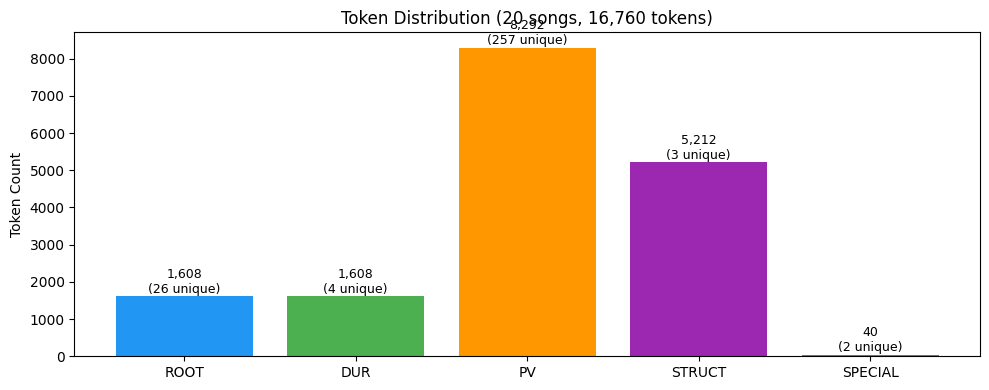

In [22]:
# Token distribution across the batch
all_tokens_flat = []
for f in test_files:
    toks = tokenizer.encode_file(str(f))
    if toks:
        all_tokens_flat.extend(toks)

counts = Counter(all_tokens_flat)

# Group by category
cats = {
    'ROOT':     [v for k, v in counts.items() if k.startswith('ROOT_')],
    'DUR':      [v for k, v in counts.items() if k.startswith('DUR_')],
    'PV':       [v for k, v in counts.items() if k.startswith('PV_')],
    'STRUCT':   [counts.get(k, 0) for k in ['CHORD_START', 'CHORD_END', 'BAR']],
    'SPECIAL':  [counts.get(k, 0) for k in ['<start>', '<end>']],
}

fig, ax = plt.subplots(figsize=(10, 4))
labels = list(cats.keys())
totals = [sum(v) for v in cats.values()]
uniq   = [len(v) for v in cats.values()]

bars = ax.bar(labels, totals, color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#607D8B'])
for bar, u, t in zip(bars, uniq, totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{t:,}\n({u} unique)', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Token Count')
ax.set_title(f'Token Distribution ({len(test_files)} songs, {len(all_tokens_flat):,} tokens)')
plt.tight_layout()
plt.show()

## 7 — Vocabulary Summary & Coverage

In [23]:
# Vocabulary coverage analysis
used_tokens = set(all_tokens_flat)
total_vocab = tokenizer.vocab_size

print(f"Vocabulary coverage ({len(test_files)} song sample):")
print(f"  Total vocab:       {total_vocab:,}")
print(f"  Tokens used:       {len(used_tokens):,}")
print(f"  Coverage:          {len(used_tokens)/total_vocab*100:.1f}%")
print(f"  Unused tokens:     {total_vocab - len(used_tokens):,}")

# Pitch range analysis
pv_steps = set()
for t in used_tokens:
    if t.startswith('PV_'):
        parts = t.split('_')
        pv_steps.add(int(parts[1]))

if pv_steps:
    print(f"\nPitch range used:")
    print(f"  Min step: {min(pv_steps)} (octave {min(pv_steps)//53})")
    print(f"  Max step: {max(pv_steps)} (octave {max(pv_steps)//53})")
    print(f"  Unique pitches: {len(pv_steps)}")
    
# Duration distribution
dur_counts = {k: v for k, v in counts.items() if k.startswith('DUR_')}
print(f"\nDuration distribution:")
for k, v in sorted(dur_counts.items(), key=lambda x: -x[1]):
    print(f"  {k:<12s} {v:>6,}  ({v/sum(dur_counts.values())*100:.1f}%)")

# Save vocabulary
vocab_path = OUTPUT_DIR / 'vocab.json'
tokenizer.save_vocab(str(vocab_path))
print(f"\nVocab saved to: {vocab_path}")

Vocabulary coverage (20 song sample):
  Total vocab:       2,623
  Tokens used:       292
  Coverage:          11.1%
  Unused tokens:     2,331

Pitch range used:
  Min step: 106 (octave 2)
  Max step: 349 (octave 6)
  Unique pitches: 91

Duration distribution:
  DUR_4.0         924  (57.5%)
  DUR_8.0         468  (29.1%)
  DUR_2.0         168  (10.4%)
  DUR_6.0          48  (3.0%)

Vocab saved to: /home/david/Projects/ANIMA_Data_Formation/dataset/preprocessed/vocab.json


## 8 — Batch Dataset Preprocessing

Run the full dual-channel preprocessing pipeline over all MIDI files.
Uses `preprocess.preprocess_dataset()`.

In [ ]:
preprocess_dataset = _preproc.preprocess_dataset

# Quick test: preprocess 50 files
test_stats = preprocess_dataset(
    midi_dir=str(MIDI_DIR),
    output_dir=str(OUTPUT_DIR / 'test'),
    tokenizer=tokenizer,
    max_files=50,
    verbose=True,
)

print(f"\nTest preprocessing complete:")
for k, v in test_stats.items():
    if k != 'eigenspace_stats':
        print(f"  {k}: {v}")

Pre-processing 0 files from /home/david/Projects/ANIMA_Data_Formation/dataset/midi_files/53_tet_mpe/

Done: 0 songs, 0 failures
  Total chords: 0
  Total tokens: 0

Saving to /home/david/Projects/ANIMA_Data_Formation/dataset/preprocessed/test/
  vocab.json (2623 tokens)
  songs/ (0 files)
  index.json
  eigenspace_stats.json
  dataset_stats.json

Test preprocessing complete:
  total_files: 0
  successful: 0
  failed: 0
  total_tokens: 0
  total_chords: 0
  vocab_size: 2623
  avg_tokens_per_song: 0.0
  avg_chords_per_song: 0.0



## 9 — Full Dataset Preprocessing

Run `preprocess_dataset()` to produce one JSON per song in `dataset/preprocessed/songs/`.
Each JSON contains `token_ids`, `eigenspace_4d`, and `chord_spans`.

> **Parallel alternative**: For the full 672k-file dataset, the parallel runner
> is much faster:
> ```bash
> python preprocess_runner.py --workers 20
> ```


In [ ]:

import time as _time
from concurrent.futures import ProcessPoolExecutor

# ── Import parallel worker functions ─────────────────────────────────────
import preprocess_runner as _run07
_worker_init        = _run07._worker_init
_worker_process_file = _run07._worker_process_file

# ── Config ───────────────────────────────────────────────────────────────
WORKERS = 20

# ── Paths ────────────────────────────────────────────────────────────────
SONGS_DIR = OUTPUT_DIR / "songs"
SONGS_DIR.mkdir(parents=True, exist_ok=True)

# ── Collect MIDI files ───────────────────────────────────────────────────
all_midi = sorted(MIDI_DIR.glob("*.mid"))
print(f"MIDI files: {len(all_midi):,}")
print(f"Output:     {SONGS_DIR}")
print(f"Workers:    {WORKERS}")

# ── Build task list ──────────────────────────────────────────────────────
tasks = [(str(f), str(SONGS_DIR)) for f in all_midi]
chunksize = max(1, min(500, len(tasks) // (WORKERS * 4)))

# ── Run parallel preprocessing ───────────────────────────────────────────
print(f"\nProcessing {len(tasks):,} files...")
print("─" * 60)

t0 = _time.time()
success, failed, total_tok, total_ch = 0, 0, 0, 0
failures = []
report_every = max(1, len(tasks) // 20)

with ProcessPoolExecutor(max_workers=WORKERS, initializer=_worker_init) as pool:
    for i, (ok, fname, n_tok, n_ch, err) in enumerate(
        pool.map(_worker_process_file, tasks, chunksize=chunksize), 1
    ):
        if ok:
            success += 1
            total_tok += n_tok
            total_ch += n_ch
        else:
            failed += 1
            if len(failures) < 10:
                failures.append(f"{fname}: {err}")

        if i % report_every == 0 or i == len(tasks):
            elapsed = _time.time() - t0
            rate = i / elapsed
            eta = (len(tasks) - i) / rate if rate > 0 else 0
            print(f"  [{i/len(tasks)*100:5.1f}%] {i:>7,}/{len(tasks):,}  "
                  f"ok={success:,}  fail={failed:,}  "
                  f"{rate:,.0f} files/s  ETA {eta:.0f}s")

elapsed = _time.time() - t0
print(f"\n{'='*60}")
print(f"Done in {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"  Success: {success:,}  |  Failed: {failed:,}")
print(f"  Tokens:  {total_tok:,}  |  Chords: {total_ch:,}")
if success > 0:
    print(f"  Avg tokens/song: {total_tok/success:.1f}")

if failures:
    print(f"\n  Sample failures:")
    for f in failures:
        print(f"    - {f}")

# ── Save vocab + stats ──────────────────────────────────────────────────
tokenizer.save_vocab(str(OUTPUT_DIR / "vocab.json"))
print(f"\nVocab saved to {OUTPUT_DIR / 'vocab.json'}")


MIDI files: 0
Output:     /home/david/Projects/ANIMA_Data_Formation/dataset/preprocessed/songs
Workers:    20

Processing 0 files...
────────────────────────────────────────────────────────────

Done in 0.0s (0.0 min)
  Success: 0  |  Failed: 0
  Tokens:  0  |  Chords: 0

Vocab saved to /home/david/Projects/ANIMA_Data_Formation/dataset/preprocessed/vocab.json



## 10 — Tokenize for Training (JSON → Memory-Mapped Binaries)

Convert the preprocessed per-song JSONs into memory-mapped `.bin` files
that GPT-2 reads directly — zero JSON parsing, zero-copy disk access.

Each song is padded to a fixed length of `block_size + 1` (4097) with `<pad>`.
Songs longer than this are split into multiple sequences.
No training window ever crosses a song boundary.

**Output files** in `dataset/tokenized/`:
| File | Type | Shape | Description |
|------|------|-------|-------------|
| `train_tokens.bin` | uint16 | `(N_seqs, 4097)` | Padded token sequences |
| `train_eigen.bin` | float16 | `(N_seqs, 4097, 4)` | EigenSpace per token |
| `val_tokens.bin` | uint16 | `(N_seqs, 4097)` | Validation sequences |
| `val_eigen.bin` | float16 | `(N_seqs, 4097, 4)` | Validation EigenSpace |
| `meta.json` | JSON | — | Vocab, splits, seq counts, stats |
| `vocab.json` | JSON | — | Token ↔ ID mapping |


In [ ]:

import shutil

# ── Reload pack_data to pick up fixed-length changes ─────────────────────
importlib.reload(importlib.import_module("pack_data"))
import pack_data as _tok08
load_songs_parallel   = _tok08.load_songs_parallel
concatenate_and_split = _tok08.concatenate_and_split
write_binary          = _tok08.write_binary

# ── Paths ────────────────────────────────────────────────────────────────
TOKENIZED_DIR = ROOT_DIR / "dataset" / "tokenized"
TOKENIZED_DIR.mkdir(parents=True, exist_ok=True)
VOCAB_PATH = OUTPUT_DIR / "vocab.json"

# ── Config ───────────────────────────────────────────────────────────────
VAL_RATIO  = 0.02
BLOCK_SIZE = 4096       # each sequence = block_size + 1 = 4097 tokens (padded)
WORKERS    = 16
SEED       = 42

# ── Collect song JSONs ───────────────────────────────────────────────────
song_files = sorted(SONGS_DIR.glob("*.json"))
print(f"Songs found: {len(song_files):,}")
print(f"Output:      {TOKENIZED_DIR}")
print(f"Val ratio:   {VAL_RATIO}  |  Block size: {BLOCK_SIZE}  |  Seed: {SEED}")

t0 = _time.time()

# ── Step 1: Load + expand eigenspace to per-token ────────────────────────
print(f"\n{'─'*60}")
print("Step 1/3: Loading and expanding eigenspace...")
all_tokens, all_eigen = load_songs_parallel(song_files, workers=WORKERS)

# ── Step 2: Train / val split + fixed-length chunking ───────────────────
print(f"\n{'─'*60}")
print("Step 2/3: Train/val split + pad to fixed-length sequences...")
data = concatenate_and_split(
    all_tokens, all_eigen,
    val_ratio=VAL_RATIO,
    block_size=BLOCK_SIZE,
    seed=SEED,
)

# ── Step 3: Write memory-mapped binaries ─────────────────────────────────
print(f"\n{'─'*60}")
print("Step 3/3: Writing binary files...")
write_binary(data['train_tokens'], TOKENIZED_DIR / "train_tokens.bin")
write_binary(data['train_eigen'],  TOKENIZED_DIR / "train_eigen.bin")
write_binary(data['val_tokens'],   TOKENIZED_DIR / "val_tokens.bin")
write_binary(data['val_eigen'],    TOKENIZED_DIR / "val_eigen.bin")

# Copy vocab
shutil.copy2(VOCAB_PATH, TOKENIZED_DIR / "vocab.json")

# ── Eigenspace statistics ────────────────────────────────────────────────
# Compute on real tokens only (exclude padding)
train_tokens_flat = data['train_tokens'].ravel()
train_eigen_flat = data['train_eigen'].reshape(-1, 4)
real_mask = train_tokens_flat != 0
te = train_eigen_flat[real_mask].astype(np.float32)

eigen_stats = {
    "alpha": {"mean": float(te[:,0].mean()), "std": float(te[:,0].std())},
    "beta":  {"mean": float(te[:,1].mean()), "std": float(te[:,1].std())},
    "gamma": {"mean": float(te[:,2].mean()), "std": float(te[:,2].std())},
    "delta": {"mean": float(te[:,3].mean()), "std": float(te[:,3].std())},
}

# ── Write meta.json ──────────────────────────────────────────────────────
with open(VOCAB_PATH) as f:
    vocab = json.load(f)

seq_len = BLOCK_SIZE + 1
meta = {
    "vocab_size": len(vocab['token_to_id']),
    "block_size": BLOCK_SIZE,
    "seq_len": seq_len,
    "val_ratio": VAL_RATIO,
    "seed": SEED,
    "n_train_songs": data['n_train_songs'],
    "n_val_songs": data['n_val_songs'],
    "n_train_seqs": data['n_train_seqs'],
    "n_val_seqs": data['n_val_seqs'],
    "n_train_tokens": int(real_mask.sum()),
    "n_val_tokens": int((data['val_tokens'].ravel() != 0).sum()),
    "total_tokens": int(real_mask.sum() + (data['val_tokens'].ravel() != 0).sum()),
    "eigenspace_dims": 4,
    "eigenspace_stats": eigen_stats,
    "dtype_tokens": "uint16",
    "dtype_eigen": "float16",
    "elapsed_seconds": round(_time.time() - t0, 1),
}
with open(TOKENIZED_DIR / "meta.json", 'w') as f:
    json.dump(meta, f, indent=2)

# ── Summary ──────────────────────────────────────────────────────────────
elapsed = _time.time() - t0
total_mb = sum(
    (TOKENIZED_DIR / f).stat().st_size
    for f in ["train_tokens.bin", "train_eigen.bin", "val_tokens.bin", "val_eigen.bin"]
) / (1024**2)

print(f"\n{'='*60}")
print(f"DONE in {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"{'='*60}")
print(f"  Train: {data['n_train_songs']:,} songs → {data['n_train_seqs']:,} seqs ({meta['n_train_tokens']:,} real tokens)")
print(f"  Val:   {data['n_val_songs']:,} songs → {data['n_val_seqs']:,} seqs ({meta['n_val_tokens']:,} real tokens)")
print(f"  Seq length: {seq_len} (block_size={BLOCK_SIZE} + 1)")
print(f"  Disk:  {total_mb:.1f} MB")
print(f"\n  EigenSpace (train, real tokens only):")
for k in ['alpha', 'beta', 'gamma', 'delta']:
    s = eigen_stats[k]
    sym = {'alpha':'α', 'beta':'β', 'gamma':'γ', 'delta':'δ'}[k]
    print(f"    {sym}: {s['mean']:.4f} ± {s['std']:.4f}")
print(f"\n  Output: {TOKENIZED_DIR}/")



---

## Architecture Reference

### Token Stream (single song)
```
<start>  BAR
  CHORD_START  DUR_4.0  ROOT_0  PV_212_3  PV_243_3  PV_265_2  PV_284_3  CHORD_END
  BAR
  CHORD_START  DUR_2.0  ROOT_31  PV_200_4  PV_231_3  PV_253_3  CHORD_END
  ...
<end>  <pad>  <pad>  <pad> ...   ← padded to block_size + 1
```

### Dual-Channel Output (per song JSON)
| Key | Type | Description |
|-----|------|-------------|
| `token_ids` | `int[]` | Flat token ID sequence |
| `eigenspace_4d` | `float[n_chords][4]` | One `(α, β, γ, δ)` per chord |
| `chord_spans` | `int[]` | Maps each token → chord index (-1 = non-chord) |
| `n_tokens` | `int` | Sequence length |
| `n_chords` | `int` | Number of chords |

### Training Binary Output (fixed-length, per-song sequences)
| File | Type | Shape |
|------|------|-------|
| `train_tokens.bin` | uint16 | `(N_seqs, 4097)` |
| `train_eigen.bin` | float16 | `(N_seqs, 4097, 4)` |
| `val_tokens.bin` | uint16 | `(N_seqs, 4097)` |
| `val_eigen.bin` | float16 | `(N_seqs, 4097, 4)` |
| `meta.json` | JSON | Vocab, splits, seq counts, stats |

> **No boundary crossing**: each sequence is exactly one song (or one chunk
> of a long song), padded with `<pad>` (id=0, ignored in loss via `ignore_index=0`).

### Training Pipeline
```
tokenizer.py  →  preprocess.py  →  pack_data.py  →  train.py
```

### Key Design Decisions
| Decision | Rationale |
|----------|-----------|
| **4D EigenSpace** `(α, β, γ, δ)` | Dissonance is root-dependent — δ = 2^(root_pc/53) completes the fingerprint |
| **Fixed-length padded sequences** | No window crosses song boundaries; `<pad>` ignored in loss |
| **block_size = 4096** | 99.7% of songs fit in one sequence (median ≈ 1753 tokens) |
| **ROOT tokens** | Explicit chord root for the model (not just from pitch sorting) |
| **Compound PV tokens** | Preserves intervallic contiguity within chords |
| **Onset-to-onset DUR** | Harmonic rhythm, not note duration |
| **No STYLE/PATTERN tokens** | Model learns structure from data, not labels |
